/var/folders/y3/qpldbqrx2dn72lflj336s6l00000gn/T/ipykernel_63709/4182222714.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  bars = sns.barplot(data=los_rates, x='time_in_hospital', y='readmit_rate', palette='coolwarm', edgecolor='black', linewidth=0.8, ci=None)
/var/folders/y3/qpldbqrx2dn72lflj336s6l00000gn/T/ipykernel_63709/4182222714.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=los_rates, x='time_in_hospital', y='readmit_rate', palette='coolwarm', edgecolor='black', linewidth=0.8, ci=None)


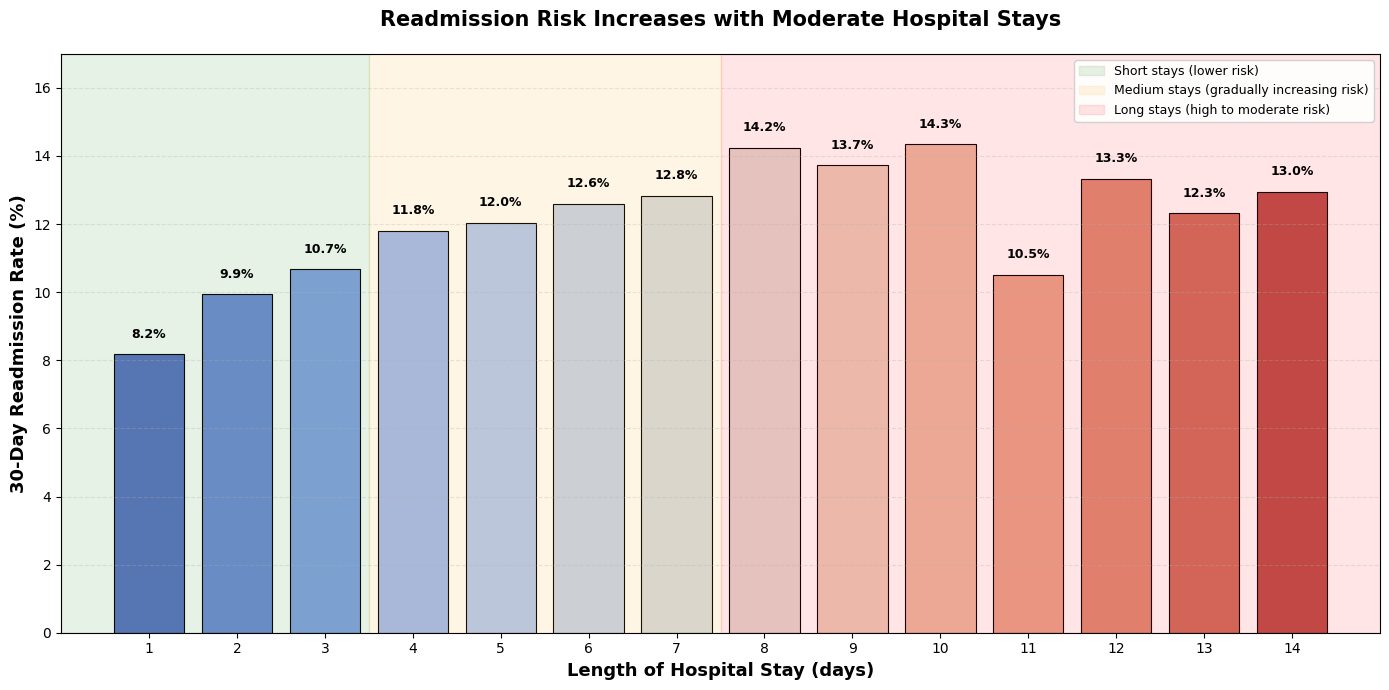

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv")
# The data is currently in CSV format for the press release, but will be document style for the actual project

# Create a binary column for hospital readmission
df['readmit_30day'] = (df['readmitted'] == '<30').astype(int)

# Calculate readmission rate for each length of stay
los_rates = df.groupby('time_in_hospital')['readmit_30day'].agg(['mean', 'count']).reset_index()
los_rates.columns = ['time_in_hospital', 'readmit_rate', 'patient_count']
los_rates['readmit_rate'] = los_rates['readmit_rate'] * 100  # percentage

# Bar plot of readmission rates by length of hospital stay 
plt.figure(figsize=(14, 7))
bars = sns.barplot(data=los_rates, x='time_in_hospital', y='readmit_rate', palette='coolwarm', edgecolor='black', linewidth=0.8, ci=None)

plt.xlabel('Length of Hospital Stay (days)', fontsize=13, fontweight='bold')
plt.ylabel('30-Day Readmission Rate (%)', fontsize=13, fontweight='bold')
plt.title('Readmission Risk Increases with Moderate Hospital Stays', fontsize=15, fontweight='bold', pad=20)
plt.ylim(0, 17)
plt.xlim(-1, 14)

# Add shaded regions to highlight patterns
plt.axvspan(-1, 2.5, alpha=0.1, color='green', label='Short stays (lower risk)')
plt.axvspan(2.5, 6.5, alpha=0.1, color='orange', label='Medium stays (gradually increasing risk)')
plt.axvspan(6.5, 14.5, alpha=0.1, color='red', label='Long stays (high to moderate risk)')

# Add value labels on top of each bar
for i, (rate, count) in enumerate(zip(los_rates['readmit_rate'], los_rates['patient_count'])):
    plt.text(i, rate + 0.4, f'{rate:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

# Download image
plt.savefig('readmission_rates_by_length_of_stay.png', dpi=300)

plt.show()